# Critical Mineral Trade Analysis on Southeast Asia - Retrospective Team
Authors: Rutvi Karnik, Ken Wang, Pranjal Patel

### Load Data and Filter by Country

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load Raw Data    
df = pd.read_csv("retrospective_raw_data.csv")

countries_keep = ["Brunei", "Cambodia", "Indonesia", "Laos", "Malaysia", "Burma", "Philippines", "Singapore", "Thailand", "Timor-Leste", "Vietnam"]
df = df[df["Countries"].isin(countries_keep)]
df.head()

,Commodities,Countries,DomesticForeign,District,Time,Value ($US) (Default Member)
0,2504 Natural Graphite,Indonesia,Foreign Exports,All Districts,2012,5852
1,2504 Natural Graphite,Indonesia,Foreign Exports,All Districts,August 2012,5852
2,2504 Natural Graphite,Malaysia,Foreign Exports,All Districts,2025,49650
3,2504 Natural Graphite,Malaysia,Foreign Exports,All Districts,November 2025,49650
4,2504 Natural Graphite,Singapore,Foreign Exports,All Districts,2012,2800


### Data Completeness Heatmap

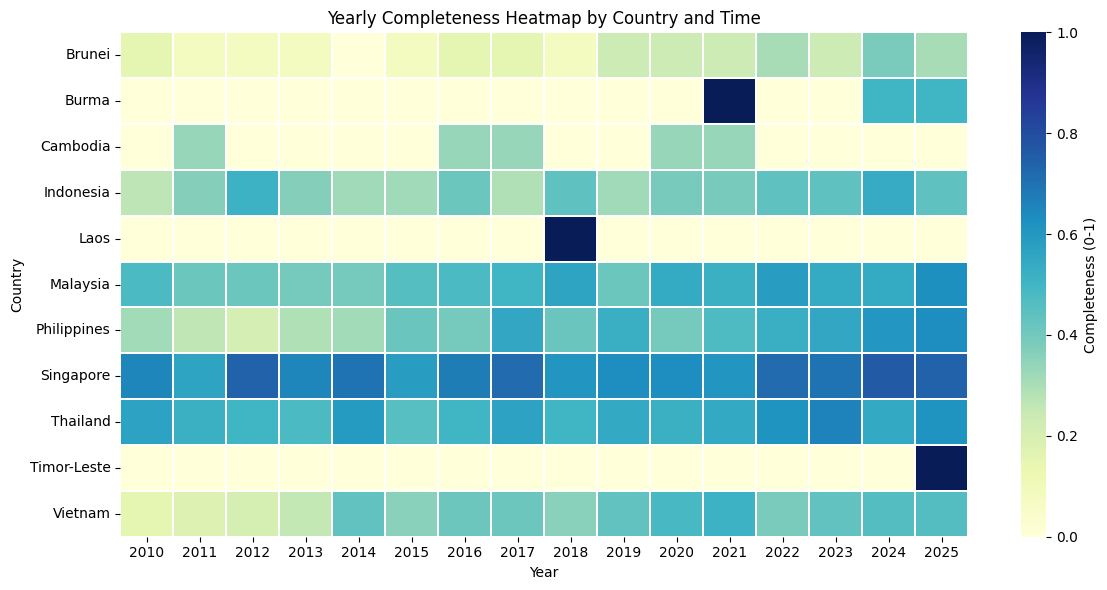

In [27]:
country_col = "Countries" if "Countries" in df.columns else None
commodity_col = "Commodities" if "Commodities" in df.columns else None
if country_col is None or commodity_col is None:
    raise ValueError("Missing Countries or Commodities column. Please check the raw data schema.")

# filter yearly data
yearly = df[df["Time"].astype(str).str.fullmatch(r"\d{4}", na=False)].copy()
yearly["year"] = pd.to_numeric(yearly["Time"], errors="coerce").astype("Int64")
yearly_plot = yearly.dropna(subset=["year"]).copy()
yearly_plot["year"] = yearly_plot["year"].astype(int)

# observed commodities per country-year
observed = yearly_plot.groupby([country_col, "year"])[commodity_col].nunique()

# total number of commodities per country over all years
total = yearly_plot.groupby(country_col)[commodity_col].nunique()

completeness = observed.div(total, level=0).rename("completeness")

# matrix for heatmap
yearly_pivot = (
    completeness.reset_index()
    .pivot(index=country_col, columns="year", values="completeness")
    .fillna(0)
    .sort_index()
    .sort_index(axis=1)
)

n_rows, n_cols = yearly_pivot.shape
fig_w = max(12, min(36, n_cols * 0.28))
fig_h = max(6, min(30, n_rows * 0.35))

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    yearly_pivot,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Completeness (0-1)"}
 )
plt.title("Yearly Completeness Heatmap by Country and Time")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Preprocessing and Cleaning

In [28]:
# Data Preprocessing
df = df.drop(columns=['DomesticForeign', 'District'])
df['HS_Code'] = df['Commodities'].astype(str).str[:4]

years = df[df['Time'].astype(str).str.strip().str.len() == 4]
years = df['Time']

# Remove rows with only year because all monthly values add up to the yearly value anyway
df = df[df['Time'].astype(str).str.strip().str.len() != 4]

# Create Month column
temp = df['Time'].str.split()
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df['Month'] = temp.str[0].map(month_map)

# Create Year column
df['Year'] = temp.str[-1].astype(int)
df = df.drop(columns = ['Time'])

df = df.rename(columns={'Value ($US) (Default Member)': 'Nominal_Value'})

# Adjusting for Inflation
inflation_rates = pd.read_csv("inflation_rates.csv")
df = df.merge(inflation_rates, on="Year")

# Use annual inflation rates for all months (i.e. for all months in 2011, use the annual inflation rate for 2011 to calculate CPI)

df['CPI'] = np.nan
curr_cpi = 100
for year in range(2010, 2026):
    inf_rate_rows = df[df['Year'] == year]
    inf_rate = inf_rate_rows['Inflation_Rate'].iloc[0] / 100

    if (year == 2010):
        df.loc[df['Year'] == 2010, 'CPI'] = curr_cpi
    else:
        curr_cpi = curr_cpi * (inf_rate + 1)
        df.loc[df['Year'] == year, 'CPI'] = curr_cpi

# Quick check that all rows have a CPI value
print("Number of rows that do not have a CPI value: ")
print(df['CPI'].isna().sum())

# Convert nominal to real values
df['Real_Value'] = ((df['Nominal_Value'] / df['CPI']) * 100).round(3)

# Adjusted commodity classification function based on keywords
def classify_commodity(commodity):
    
    commodity = commodity.lower().strip()

    # Ore/Raw
    ore_keywords = ["ores", "concentrates", "mattes", "scrap", "waste"]
    if any(word in commodity for word in ore_keywords):
        return "Ore/Raw"

    # Compound
    compound_keywords = ["oxide", "chloride", "sulphate", "carbonate", "compound"]
    if any(word in commodity for word in compound_keywords):
        return "Compound"

    # Advanced Product
    advanced_keywords = ["battery", "magnet"]
    if any(word in commodity for word in advanced_keywords):
        return "Advanced Product"

    # Refined/Articles
    refined_keywords = ["unwrought", "bars", "rods", "wire", "plates", "sheets",
                        "strip", "foil", "tubes", "pipes", "articles", "structures",
                        "containers", "alloys"]
    if any(word in commodity for word in refined_keywords):
        return "Refined/Articles"

    # Other
    return "Other"

# Create Category Type column
df["CategoryType"] = df["Commodities"].apply(classify_commodity)

# Missing Values
print("\nTotal Missing Values: \n{}\n".format(df.isna().sum()))
# Even though there are 0 missing values, we do not have complete time-series data. 
# Some countries have missing data from certain years which does not show up even in the .csv file

# Convert to type numeric
df["Nominal_Value"] = pd.to_numeric(df["Nominal_Value"])
df["Real_Value"] = pd.to_numeric(df["Real_Value"])
print(df.info())
# Year and Month are already numeric

# Check for negative values
negative_nom = (df["Nominal_Value"] < 0).sum()
negative_real = (df["Real_Value"] < 0).sum()
print("\nNegative Values in 'Nominal Value': {0}\nNegative Values in 'Real Value': {1}".format(negative_nom, negative_real))

# Duplicate rows
print("\nDuplicate Rows: {}".format(df.duplicated().sum()))

# Duplicate dates
duplicates = df.duplicated(subset=["Year", "Month", "HS_Code", "Countries"], keep=False)
print("\nNumber of Duplicate Dates: {}".format(len(df[duplicates])))

df.head()


Number of rows that do not have a CPI value: 
0

Total Missing Values: 
Commodities       0
Countries         0
Nominal_Value     0
HS_Code           0
Month             0
Year              0
Inflation_Rate    0
CPI               0
Real_Value        0
CategoryType      0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Commodities     8238 non-null   object 
 1   Countries       8238 non-null   object 
 2   Nominal_Value   8238 non-null   int64  
 3   HS_Code         8238 non-null   object 
 4   Month           8238 non-null   int64  
 5   Year            8238 non-null   int64  
 6   Inflation_Rate  8238 non-null   float64
 7   CPI             8238 non-null   float64
 8   Real_Value      8238 non-null   float64
 9   CategoryType    8238 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 643.7+ KB
Non

,Commodities,Countries,Nominal_Value,HS_Code,Month,Year,Inflation_Rate,CPI,Real_Value,CategoryType
0,2504 Natural Graphite,Indonesia,5852,2504,8,2012,1.7,104.751000,5586.582,Other
1,2504 Natural Graphite,Malaysia,49650,2504,11,2025,2.7,148.078914,33529.419,Other
2,2504 Natural Graphite,Singapore,2800,2504,7,2012,1.7,104.751000,2673.006,Other
3,2504 Natural Graphite,Thailand,110900,2504,10,2020,1.4,118.919611,93256.276,Other
4,2504 Natural Graphite,Thailand,10269,2504,12,2020,1.4,118.919611,8635.245,Other


#### Outliers

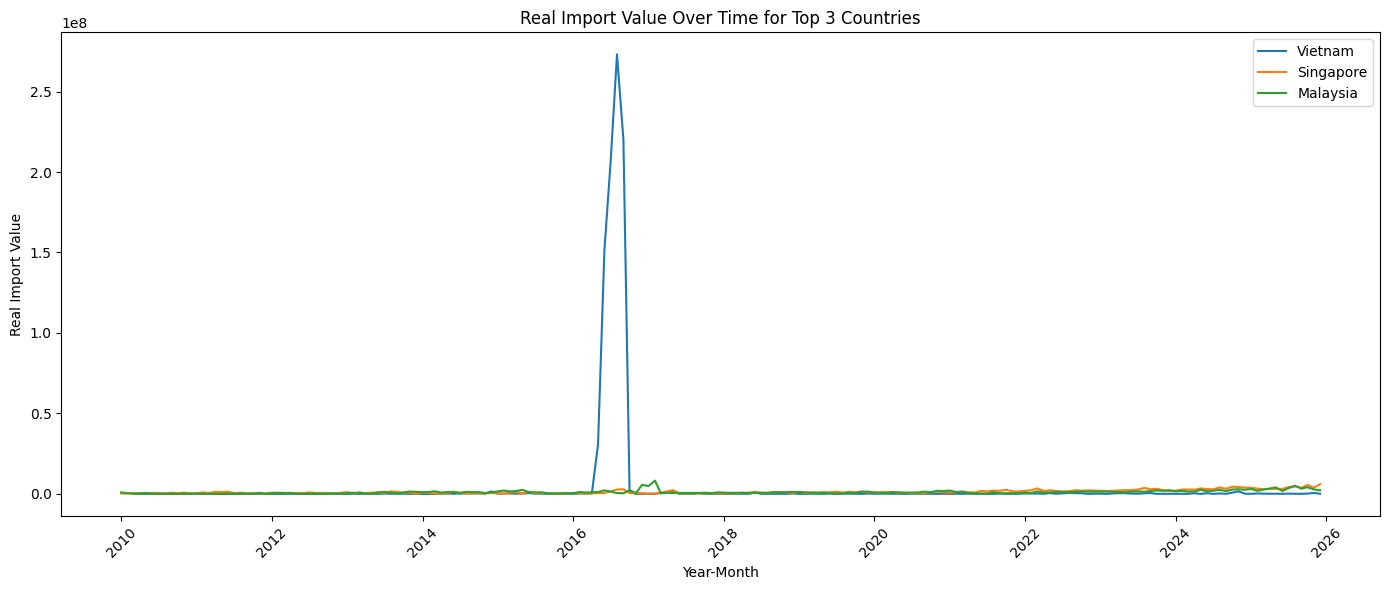

In [29]:
df["YearMonth"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

country_totals = (
    df.groupby('Countries')['Real_Value']
      .sum()
      .sort_values(ascending=False)
)

top3 = country_totals.head(3).index.tolist()

plt.figure(figsize=(14, 6))
for country in top3:
    subset = df[df["Countries"] == country]
    monthly_country = (
        subset.groupby("YearMonth")["Real_Value"]
              .sum()
              .sort_index()
    )
    plt.plot(monthly_country.index, monthly_country.values, label=country)

plt.title("Real Import Value Over Time for Top 3 Countries")
plt.xlabel("Year-Month")
plt.ylabel("Real Import Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There seems to be a massive spike in real value imports from Vietnam between 2016-2017

In [30]:
df_vietnam16 = df[(df["Countries"] == "Vietnam") & (df["Year"].between(2016, 2017))]
df_vietnam16.sort_values(by="Real_Value", ascending=False).head(5)

,Commodities,Countries,Nominal_Value,HS_Code,Month,Year,Inflation_Rate,CPI,Real_Value,CategoryType,YearMonth
4477,"7604 Aluminum Bars, Rods And Profiles",Vietnam,300938633,7604,8,2016,2.1,110.189437,2.731102e+08,Refined/Articles,2016-08-01
4478,"7604 Aluminum Bars, Rods And Profiles",Vietnam,242538320,7604,9,2016,2.1,110.189437,2.201103e+08,Refined/Articles,2016-09-01
4476,"7604 Aluminum Bars, Rods And Profiles",Vietnam,227177808,7604,7,2016,2.1,110.189437,2.061702e+08,Refined/Articles,2016-07-01
4475,"7604 Aluminum Bars, Rods And Profiles",Vietnam,166927544,7604,6,2016,2.1,110.189437,1.514914e+08,Refined/Articles,2016-06-01
4474,"7604 Aluminum Bars, Rods And Profiles",Vietnam,33865414,7604,5,2016,2.1,110.189437,3.073381e+07,Refined/Articles,2016-05-01


The nominal value for Vietnam's import of "7604 Aluminum Bars, Rods and Profiles" in August 2016 is $300 million. Let's do a quick check to see if it exists in the raw dataset.

In [31]:
temp_df = pd.read_csv("retrospective_raw_data.csv")
temp_df_vietnam16 = temp_df[(temp_df["Countries"] == "Vietnam") & (temp_df["Time"] == "August 2016")]
temp_df_vietnam16.sort_values(by="Value ($US) (Default Member)", ascending=False).head(5)

,Commodities,Countries,DomesticForeign,District,Time,Value ($US) (Default Member)
5655,"7604 Aluminum Bars, Rods And Profiles",Vietnam,Foreign Exports,All Districts,August 2016,300938633
10192,"8108 Titanium & Articles Thereof, Includ Waste...",Vietnam,Foreign Exports,All Districts,August 2016,6961


It seems like the spike is not a problem caused by our preprocessing steps, but that the value originally exists in the raw dataset. According to a 2018 U.S. Department of Commerce report, this spike may have been effect of transshipments originally from China.

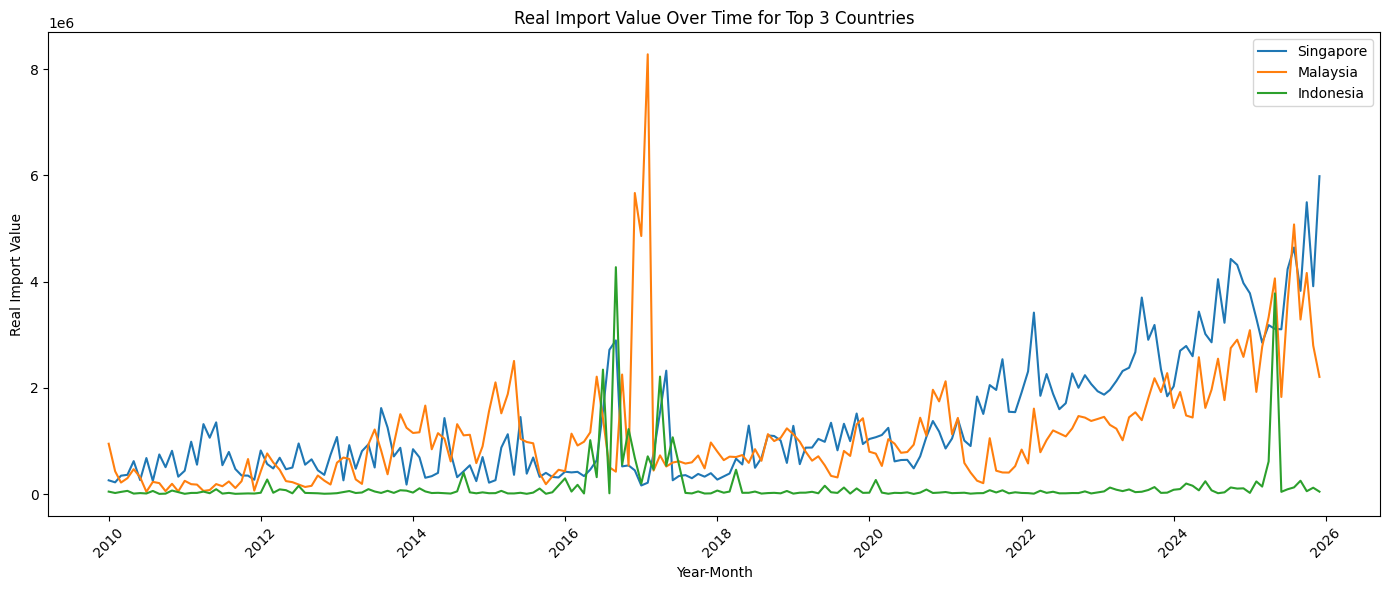

In [32]:
# Outliers without Vietnam:

country_totals_no_vietnam = (
    df[df["Countries"] != "Vietnam"]
      .groupby('Countries')['Real_Value']
      .sum()
      .sort_values(ascending=False)
)

top3_no_vietnam = country_totals_no_vietnam.head(3).index.tolist()

plt.figure(figsize=(14, 6))
for country in top3_no_vietnam:
    subset = df[df["Countries"] == country]
    monthly_country = (
        subset.groupby("YearMonth")["Real_Value"]
              .sum()
              .sort_index()
    )
    plt.plot(monthly_country.index, monthly_country.values, label=country)

plt.title("Real Import Value Over Time for Top 3 Countries")
plt.xlabel("Year-Month")
plt.ylabel("Real Import Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Save Cleaned Dataset

In [33]:
df.to_csv("retrospective_data_cleaned.csv", index = False)
print("End of Preprocessing and Cleaning")

End of Preprocessing and Cleaning
